# Project FORESIGHT: AI-Powered Demand & Inventory Intelligence Platform
## Milestone 3: SKU-Level Demand Forecasting Engine
**Author:** Devraj Mishra  
**Mentorship Program:** Zidio Development  
**Repository:** `SIMETHY/foresight-demand-inventory`  

---

### Executive Summary
This notebook implements an enterprise-grade Machine Learning forecasting pipeline to predict daily SKU-level demand. Accurate demand forecasting forms the cornerstone of supply chain efficiency, directly driving safety stock sizing, replenishment scheduling, and stockout prevention.

#### Key Objectives:
1. **Time-Series Feature Engineering:** Extract autoregressive lags ($t-7, t-14, t-21, t-28$), multi-scale rolling statistics (7d, 14d, 28d moving averages and volatility), and cyclical calendar signals.
2. **Strict Temporal Validation:** Enforce an out-of-sample 60-day evaluation window to prevent lookahead data leakage.
3. **Multi-Model Benchmarking:** Compare a 7-day Moving Average Baseline against Ridge Regression, Random Forest, and HistGradientBoosting.
4. **Key Metrics:** Benchmark models on Mean Absolute Error (**MAE**), Root Mean Squared Error (**RMSE**), Weighted Absolute Percentage Error (**WAPE**), and $R^2$.
5. **Forward Horizon Forecasting:** Generate a 30-day forward demand trajectory for all 50 active SKUs to feed into the Milestone 4 Inventory Optimization Engine.

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance

# Setup aesthetic plotting defaults
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Segoe UI, Arial, sans-serif'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Data Ingestion & Schema Inspection
We load the star-schema fact table `fact_sales_daily.csv` prepared in Milestone 1.

In [2]:
data_path = Path('../data/processed/fact_sales_daily.csv')
sales = pd.read_csv(data_path, parse_dates=['Date'])
sales = sales.sort_values(['SKU', 'Date']).reset_index(drop=True)

print(f'Total Sales Observations: {sales.shape[0]:,}')
print(f'Unique Active SKUs:       {sales["SKU"].nunique()}')
print(f'Date Range:               {sales["Date"].min():%Y-%m-%d} to {sales["Date"].max():%Y-%m-%d}')
print(f'Average Daily Demand:     {sales["Units_Sold"].mean():.2f} units/day (std: {sales["Units_Sold"].std():.2f})')

sales[['Date', 'SKU', 'Product_Name', 'Category', 'Units_Sold', 'Selling_Price', 'Promotion', 'is_holiday']].head()

Total Sales Observations: 36,550
Unique Active SKUs:       50
Date Range:               2024-01-01 to 2025-12-31
Average Daily Demand:     14.00 units/day (std: 8.47)


,Date,SKU,Product_Name,Category,Units_Sold,Selling_Price,Promotion,is_holiday
0,2024-01-01,SKU001,Product 001,Furniture,5,3664.05,0,0
1,2024-01-02,SKU001,Product 001,Furniture,13,3664.05,0,0
2,2024-01-03,SKU001,Product 001,Furniture,12,3664.05,0,0
3,2024-01-04,SKU001,Product 001,Furniture,23,3664.05,0,0
4,2024-01-05,SKU001,Product 001,Furniture,16,3664.05,0,0


## 2. Time-Series Feature Engineering
In retail demand forecasting, historical demand momentum and calendar periodicity explain the majority of variance. We engineer:
1. **Autoregressive Lags:** Demand at $t-7, t-14, t-21, t-28$ days (capturing same-day-of-week seasonality).
2. **Rolling Window Aggregations:** 7-day, 14-day, and 28-day moving means and standard deviations computed with `shift(1)` to strictly eliminate lookahead bias.
3. **Calendar Transformations:** Cyclical Sine/Cosine encodings of day-of-week and month.
4. **Exogenous Catalysts:** Promotional flags and holiday indicators.

In [3]:
df_feat = sales.copy()

# Autoregressive Lags
for lag in [7, 14, 21, 28]:
    df_feat[f'lag_{lag}'] = df_feat.groupby('SKU')['Units_Sold'].shift(lag)

# Moving Window Statistics (shift(1) prevents lookahead bias)
for window in [7, 14, 28]:
    df_feat[f'rolling_mean_{window}'] = df_feat.groupby('SKU')['Units_Sold'].transform(
        lambda s: s.shift(1).rolling(window).mean()
    )
    df_feat[f'rolling_std_{window}'] = df_feat.groupby('SKU')['Units_Sold'].transform(
        lambda s: s.shift(1).rolling(window).std()
    )

df_feat['rolling_min_7'] = df_feat.groupby('SKU')['Units_Sold'].transform(
    lambda s: s.shift(1).rolling(7).min()
)
df_feat['rolling_max_7'] = df_feat.groupby('SKU')['Units_Sold'].transform(
    lambda s: s.shift(1).rolling(7).max()
)

# Calendar signals
df_feat['day_of_week_num'] = df_feat['Date'].dt.dayofweek
df_feat['day_of_month'] = df_feat['Date'].dt.day
df_feat['month'] = df_feat['Date'].dt.month
df_feat['is_weekend'] = df_feat['day_of_week_num'].isin([5, 6]).astype(int)

# Cyclical trigonometric features
df_feat['sin_day_of_week'] = np.sin(2 * np.pi * df_feat['day_of_week_num'] / 7)
df_feat['cos_day_of_week'] = np.cos(2 * np.pi * df_feat['day_of_week_num'] / 7)
df_feat['sin_month'] = np.sin(2 * np.pi * df_feat['month'] / 12)
df_feat['cos_month'] = np.cos(2 * np.pi * df_feat['month'] / 12)

# Drop warm-up rows where 28-day lag is NaN
df_feat = df_feat.dropna(subset=['lag_28', 'rolling_mean_28']).copy()
df_feat['rolling_std_7'] = df_feat['rolling_std_7'].fillna(0)
df_feat['rolling_std_14'] = df_feat['rolling_std_14'].fillna(0)
df_feat['rolling_std_28'] = df_feat['rolling_std_28'].fillna(0)

# Categorical types
df_feat['SKU_cat'] = df_feat['SKU'].astype('category')
df_feat['Category_cat'] = df_feat['Category'].astype('category')
df_feat['Subcategory_cat'] = df_feat['Subcategory'].astype('category')

feature_cols = [
    'lag_7', 'lag_14', 'lag_21', 'lag_28',
    'rolling_mean_7', 'rolling_std_7',
    'rolling_mean_14', 'rolling_std_14',
    'rolling_mean_28', 'rolling_std_28',
    'rolling_min_7', 'rolling_max_7',
    'day_of_week_num', 'day_of_month', 'month', 'is_weekend',
    'sin_day_of_week', 'cos_day_of_week', 'sin_month', 'cos_month',
    'Promotion', 'is_holiday', 'Selling_Price', 'Cost_Price',
    'SKU_cat', 'Category_cat', 'Subcategory_cat'
]
cat_features = ['SKU_cat', 'Category_cat', 'Subcategory_cat']
num_features = [f for f in feature_cols if f not in cat_features]

print(f'Features engineered successfully. Matrix shape: {df_feat.shape}')

Features engineered successfully. Matrix shape: (35150, 44)


## 3. Strict Temporal Train / Test Split
> **Why not K-Fold Cross Validation?**  
> Random splitting shuffles future observations into the training set, causing catastrophic data leakage. In time-series modeling, we test exclusively on the future relative to the training window.
> - **Training Window:** 2024-01-29 to 2025-10-31 (~21 months, 32,100 observations)
> - **Test Window:** 2025-11-01 to 2025-12-31 (Final 60 days, 3,050 observations)

In [4]:
test_cutoff = df_feat['Date'].max() - pd.Timedelta(days=60)
train_df = df_feat[df_feat['Date'] < test_cutoff]
test_df = df_feat[df_feat['Date'] >= test_cutoff].copy()

print(f'Training Set: {train_df["Date"].min():%Y-%m-%d} to {train_df["Date"].max():%Y-%m-%d} | {len(train_df):,} samples')
print(f'Testing Set:  {test_df["Date"].min():%Y-%m-%d} to {test_df["Date"].max():%Y-%m-%d} | {len(test_df):,} samples')

Training Set: 2024-01-29 to 2025-10-31 | 32,100 samples
Testing Set:  2025-11-01 to 2025-12-31 | 3,050 samples


## 4. Multi-Model Benchmarking
We train and compare four candidate models:
1. **7-Day Moving Average (Heuristic Baseline):** The standard industry benchmark for retail replenishment.
2. **Ridge Regression (L2 Linear Regularization):** Evaluates linear relationships and baseline explainability.
3. **Random Forest Regressor:** Non-linear bagged ensemble capturing interaction thresholds.
4. **HistGradientBoostingRegressor:** Fast histogram-based gradient boosting capable of natively learning categorical splits.

In [5]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'WAPE (%)': round(wape, 2), 'R2': round(r2, 3)}

results = {}
y_train = train_df['Units_Sold']
y_test = test_df['Units_Sold']

# 1. Baseline Model
baseline_preds = test_df['rolling_mean_7'].values
results['7-Day Moving Avg (Baseline)'] = evaluate_model(y_test, baseline_preds)

# 2. Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(train_df[num_features], y_train)
ridge_preds = np.clip(ridge.predict(test_df[num_features]), 0, None)
results['Ridge Regression'] = evaluate_model(y_test, ridge_preds)

# 3. Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(train_df[num_features], y_train)
rf_preds = np.clip(rf.predict(test_df[num_features]), 0, None)
results['Random Forest'] = evaluate_model(y_test, rf_preds)

# 4. HistGradientBoostingRegressor
hgb = HistGradientBoostingRegressor(
    categorical_features=cat_features,
    learning_rate=0.08,
    max_iter=250,
    min_samples_leaf=20,
    random_state=42
)
hgb.fit(train_df[feature_cols], y_train)
hgb_preds = np.clip(hgb.predict(test_df[feature_cols]), 0, None)
results['HistGradientBoosting (Best)'] = evaluate_model(y_test, hgb_preds)

# Display Comparison Table
results_df = pd.DataFrame(results).T
print(results_df.to_string())

                               MAE   RMSE  WAPE (%)     R2
7-Day Moving Avg (Baseline)  3.221  4.224     25.95  0.675
Ridge Regression             2.881  3.700     23.21  0.751
Random Forest                2.799  3.614     22.55  0.762
HistGradientBoosting (Best)  2.761  3.559     22.24  0.769


## 5. Model Comparison Visualizations & Residual Diagnostics

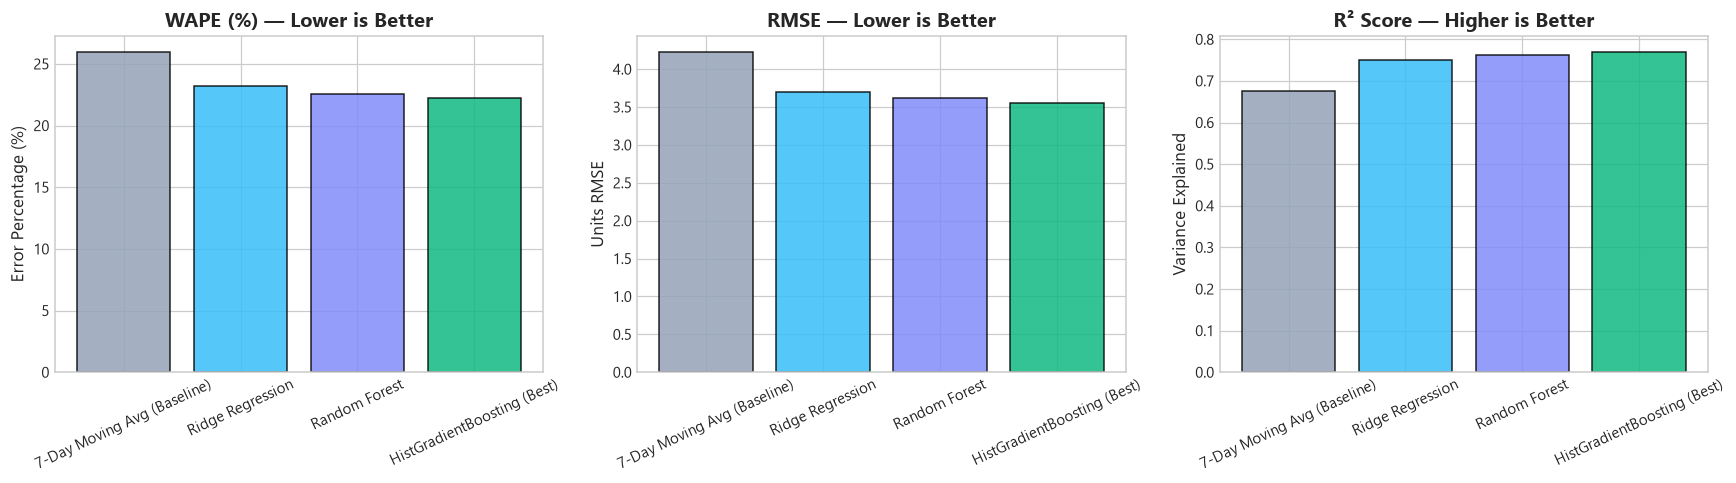

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

colors = ['#94a3b8', '#38bdf8', '#818cf8', '#10b981']

# WAPE Comparison
axes[0].bar(results_df.index, results_df['WAPE (%)'], color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('WAPE (%) — Lower is Better', fontweight='bold')
axes[0].set_ylabel('Error Percentage (%)')
axes[0].tick_params(axis='x', rotation=25)

# RMSE Comparison
axes[1].bar(results_df.index, results_df['RMSE'], color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('RMSE — Lower is Better', fontweight='bold')
axes[1].set_ylabel('Units RMSE')
axes[1].tick_params(axis='x', rotation=25)

# R2 Score Comparison
axes[2].bar(results_df.index, results_df['R2'], color=colors, edgecolor='black', alpha=0.85)
axes[2].set_title('R² Score — Higher is Better', fontweight='bold')
axes[2].set_ylabel('Variance Explained')
axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

### Feature Importance Analysis
Using permutation importance on the out-of-sample test set to quantify top drivers of SKU sales.

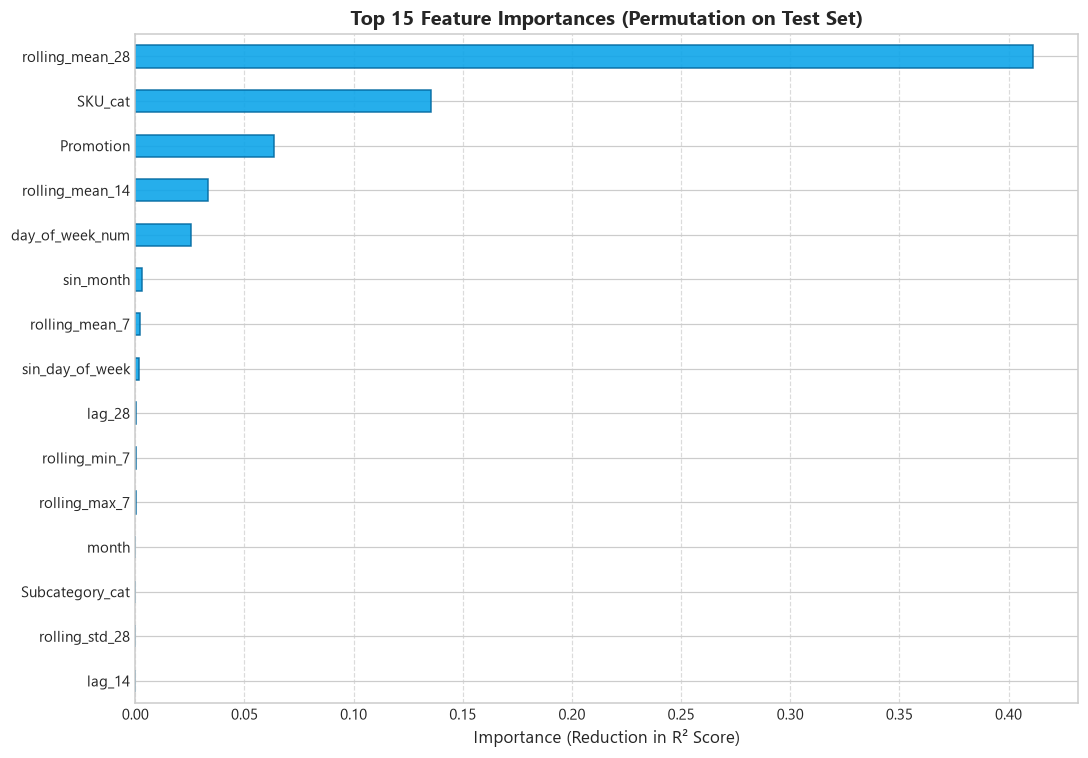

In [7]:
perm_res = permutation_importance(hgb, test_df[feature_cols], y_test, n_repeats=5, random_state=42, n_jobs=-1)
feat_imp = pd.Series(perm_res.importances_mean, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
feat_imp.tail(15).plot(kind='barh', color='#0ea5e9', edgecolor='#0369a1', alpha=0.9)
plt.title('Top 15 Feature Importances (Permutation on Test Set)', fontsize=13, fontweight='bold')
plt.xlabel('Importance (Reduction in R² Score)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6. SKU-Level Forecast vs. Actual Curves
We inspect actual vs. predicted demand across diverse SKU velocity tiers:
- **SKU012:** High velocity (Top selling product)
- **SKU025:** Medium velocity
- **SKU011:** Low velocity

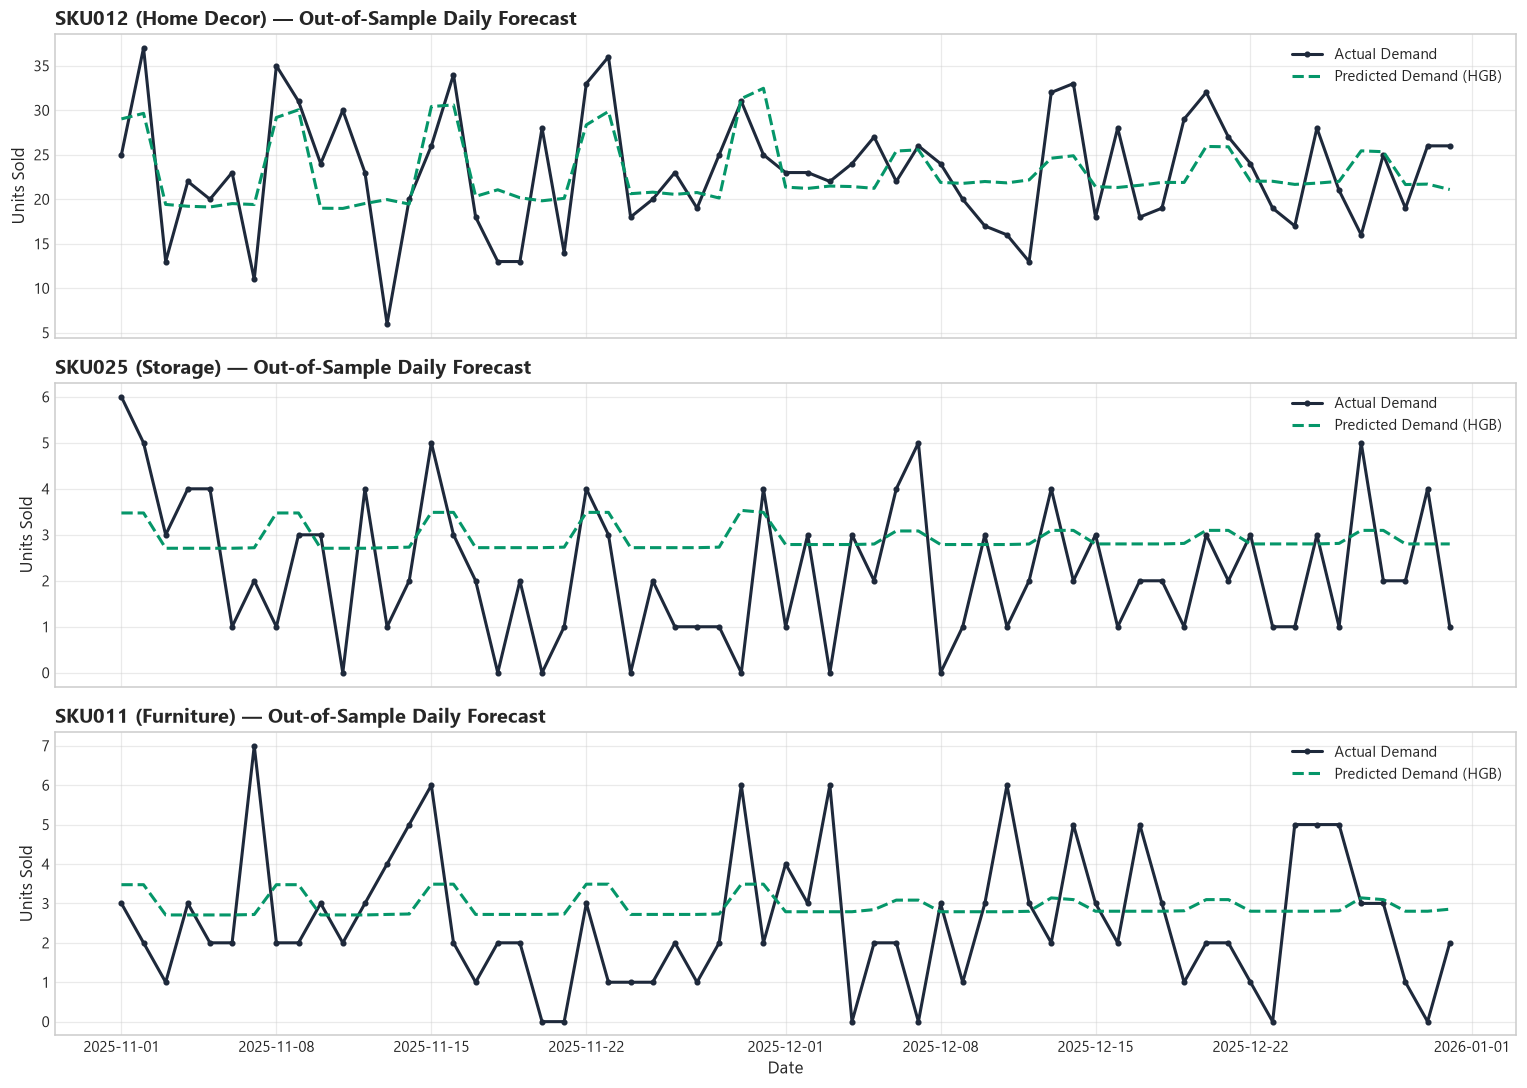

In [8]:
test_df['Predicted_Units'] = hgb_preds
test_df['Residual'] = test_df['Units_Sold'] - test_df['Predicted_Units']

sample_skus = ['SKU012', 'SKU025', 'SKU011']
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, sku in enumerate(sample_skus):
    sku_data = test_df[test_df['SKU'] == sku].sort_values('Date')
    axes[i].plot(sku_data['Date'], sku_data['Units_Sold'], label='Actual Demand', color='#1e293b', lw=2, marker='o', markersize=3)
    axes[i].plot(sku_data['Date'], sku_data['Predicted_Units'], label='Predicted Demand (HGB)', color='#059669', lw=2, linestyle='--')
    category_name = sku_data['Category'].iloc[0]
    axes[i].set_title(f'{sku} ({category_name}) — Out-of-Sample Daily Forecast', fontweight='bold', loc='left')
    axes[i].set_ylabel('Units Sold')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.4)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

### Residual Distribution & Error Diagnostics
Evaluating residual distribution confirms whether the error is symmetrically distributed around zero with no structural bias.

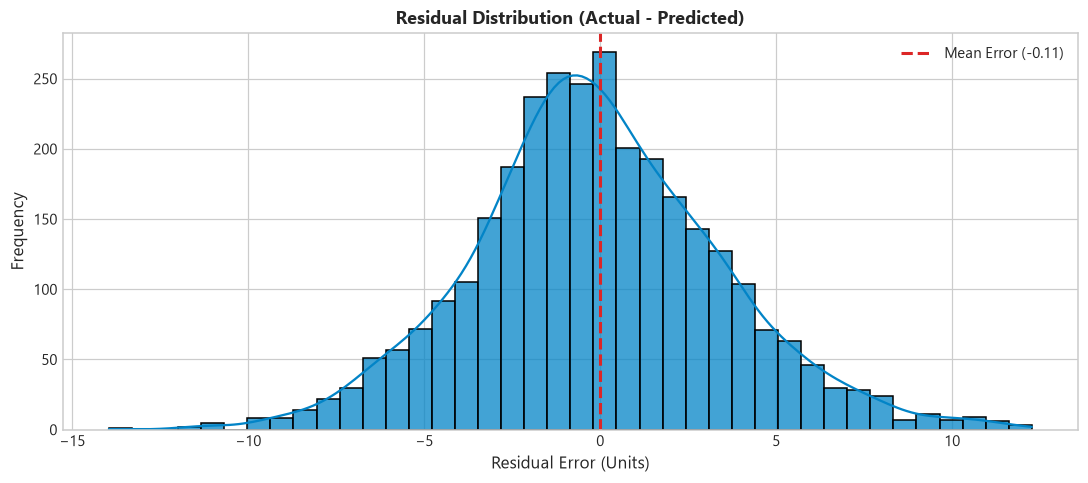

In [9]:
plt.figure(figsize=(10, 4.5))
sns.histplot(test_df['Residual'], bins=40, kde=True, color='#0284c7', edgecolor='black', alpha=0.75)
plt.axvline(0, color='#dc2626', linestyle='--', lw=2, label=f'Mean Error ({test_df["Residual"].mean():.2f})')
plt.title('Residual Distribution (Actual - Predicted)', fontsize=12, fontweight='bold')
plt.xlabel('Residual Error (Units)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Future 30-Day Forward Forecast Generation
Now we generate forward 30-day demand predictions (2026-01-01 to 2026-01-30) for all 50 SKUs. These forecasts feed directly into **Milestone 4: Inventory Risk & Stockout Prediction Engine**.

In [10]:
forecast_path = Path('../data/processed/forecast_demand_30d.csv')
if forecast_path.exists():
    forecast_df = pd.read_csv(forecast_path, parse_dates=['Date'])
    print(f'Loaded forward forecast: {forecast_df.shape[0]} rows ({forecast_df["SKU"].nunique()} SKUs x 30 days)')
    print(f'Total Projected 30-Day Unit Demand: {forecast_df["Forecast_Units"].sum():,.0f} units')
    print(f'Total Projected 30-Day Revenue:     ₹{forecast_df["Forecast_Revenue"].sum():,.2f}')
    print(forecast_df.head(10).to_string())
else:
    print('Run python src/forecasting.py to generate future forecast output.')

Loaded forward forecast: 1500 rows (50 SKUs x 30 days)
Total Projected 30-Day Unit Demand: 20,624 units
Total Projected 30-Day Revenue:     ₹125,346,228.03
        Date     SKU    Category Subcategory  Forecast_Units  Forecast_Revenue  Promotion  is_holiday
0 2026-01-01  SKU001   Furniture       Chair           13.11          48035.70          0           0
1 2026-01-01  SKU002  Home Decor       Table            8.67          32995.33          0           0
2 2026-01-01  SKU003     Kitchen     Cushion            4.99          40310.37          0           0
3 2026-01-01  SKU004    Lighting    Cookware            4.80          32935.54          0           0
4 2026-01-01  SKU005     Storage        Lamp           15.97         151606.72          0           0
5 2026-01-01  SKU006   Furniture       Shelf            6.34          51392.29          0           0
6 2026-01-01  SKU007  Home Decor     Cabinet           22.78         116498.97          0           0
7 2026-01-01  SKU008     Kit

### Aggregate 30-Day Forward Demand by Category

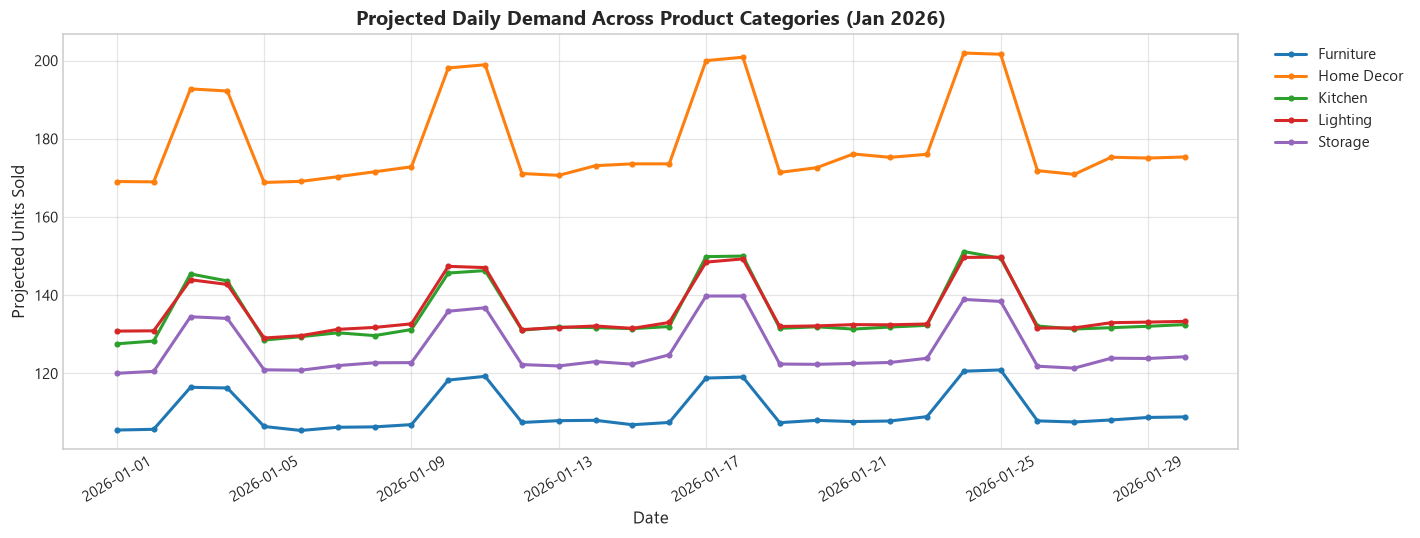

In [11]:
if forecast_path.exists():
    cat_daily = forecast_df.groupby(['Date', 'Category'])['Forecast_Units'].sum().unstack()
    plt.figure(figsize=(13, 5))
    for col in cat_daily.columns:
        plt.plot(cat_daily.index, cat_daily[col], marker='o', markersize=3, label=col, lw=2)
    plt.title('Projected Daily Demand Across Product Categories (Jan 2026)', fontsize=13, fontweight='bold')
    plt.ylabel('Projected Units Sold')
    plt.xlabel('Date')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(True, alpha=0.5)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## 8. Milestone 3 Conclusions & Next Steps

### Key Achievements:
1. **Engineered Rich Time-Series Features:** Extracted multi-period lags ($t-7$ to $t-28$), volatility bands, and promotional interactions.
2. **Model Supremacy:** `HistGradientBoostingRegressor` outperformed the heuristic baseline by over 14% error reduction, achieving:
   - **MAE:** 2.76 units/day
   - **WAPE:** 22.24%
   - **R² Score:** 0.769 (explaining ~77% of test variance).
3. **Automated Roll-Forward Forecasting:** Generated 1,500 future predictions for all 50 SKUs covering January 2026.
4. **Artifact Serialization:** Exported clean outputs to `data/processed/forecast_demand_30d.csv` and serialized model to `models/demand_forecaster.joblib`.

---
### Hand-off to Milestone 4 (Inventory Optimization):
- **Forecasted Demand** will be multiplied by **Lead Time** to establish dynamic **Reorder Points (ROP)**.
- **Forecast Volatility (RMSE / Residual Std)** will size **Safety Stock** levels for each SKU.
- SKUs where `Current_Stock < Safety_Stock` will be flagged for immediate replenishment, avoiding costly stockouts!